# Riyadh HeatReady — reproducible priority ranking

**Question:** Which 1 km zones in southeastern Riyadh should a municipal planning and heat-resilience team inspect first?

This notebook reproduces the final decision score from a small committed sample. The input columns were derived by the full Earth-observation pipeline from open Sentinel-1, Sentinel-2, Landsat, annual land cover, and WorldPop data. The full download and processing code is in `src/run_analysis.py`; the exact scene IDs and dates are in `config.json`.

The sample does **not** replace the raw-satellite workflow. It makes the final ranking easy for judges to run without downloading several gigabytes.


## Method in plain language

Each eligible grid cell already contains four normalized values from 0 to 1:

- **heat** — hotter land surfaces score higher;

- **population** — more modelled residents score higher;

- **growth** — a larger confirmed new-built fraction scores higher;

- **lack of green** — less vegetation scores higher.

The PoC score is `100 × (40% heat + 30% population + 20% growth + 10% lack of green)`. The top 20% are labelled **High**, the next 30% **Medium**, and the rest **Watch**. These weights are transparent PoC assumptions, not official municipal policy.


In [1]:
from pathlib import Path

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt



# This works from the repository root or from inside notebooks/.

cwd = Path.cwd().resolve()

ROOT = cwd if (cwd / "config.json").exists() else cwd.parent

INPUT = ROOT / "data" / "sample_input" / "riyadh_priority_drivers.csv"

RESULTS = ROOT / "results"

RESULTS.mkdir(exist_ok=True)

print(f"Repository root: {ROOT}")

print(f"Input: {INPUT.relative_to(ROOT)}")


Repository root: C:\Users\yusuf\Documents\Codex\2026-09-08\space-academy-hackathon\project
Input: data\sample_input\riyadh_priority_drivers.csv


In [2]:
zones = pd.read_csv(INPUT)

required = [

    "grid_id", "longitude", "latitude", "lst_mean_c",

    "population_estimate", "new_built_fraction", "ndvi_mean_2025",

    "heat_component", "population_component", "growth_component",

    "lack_green_component",

]

missing = sorted(set(required) - set(zones.columns))

assert not missing, f"Missing columns: {missing}"

assert len(zones) == 67, f"Expected 67 eligible zones, found {len(zones)}"

assert zones[required].notna().all().all(), "Input contains missing values"

print(f"Loaded {len(zones)} eligible 1 km zones with no missing required values.")

zones.head(3)


Loaded 67 eligible 1 km zones with no missing required values.


,grid_id,row,col,longitude,latitude,lst_mean_c,population_estimate,built_fraction_2018,built_fraction_2025,new_built_fraction,aoi_coverage_fraction,ndvi_mean_2025,heat_component,population_component,growth_component,lack_green_component
0,R05C10,4,9,46.842269,24.614391,50.792603,3818.000244,0.795592,0.759868,0.071096,1.0,0.022700,0.880597,0.611940,0.791045,0.925373
1,R02C10,1,9,46.842666,24.641471,51.589489,3457.641357,0.870417,0.705135,0.057860,1.0,0.017754,0.985075,0.507463,0.686567,0.985075
2,R03C10,2,9,46.842534,24.632444,51.079086,3414.152344,0.607700,0.564616,0.069726,1.0,0.030390,0.910448,0.477612,0.761194,0.865672


## Recalculate the score

Keeping the formula visible makes the result auditable. A real user should review the weights before operational use.


In [3]:
weights = {

    "heat_component": 0.40,

    "population_component": 0.30,

    "growth_component": 0.20,

    "lack_green_component": 0.10,

}

zones["priority_score"] = 100 * sum(

    zones[column] * weight for column, weight in weights.items()

)

high_cut = zones["priority_score"].quantile(0.80)

medium_cut = zones["priority_score"].quantile(0.50)

zones["priority_class"] = np.select(

    [zones["priority_score"] >= high_cut, zones["priority_score"] >= medium_cut],

    ["High", "Medium"],

    default="Watch",

)

zones = zones.sort_values(["priority_score", "grid_id"], ascending=[False, True])

assert zones.iloc[0]["grid_id"] == "R05C10"

assert np.isclose(zones.iloc[0]["priority_score"], 78.656723, atol=1e-5)

print(f"High threshold: {high_cut:.2f}; medium threshold: {medium_cut:.2f}")

zones[["grid_id", "priority_score", "priority_class", "lst_mean_c", "population_estimate", "new_built_fraction"]].head(10)


High threshold: 62.54; medium threshold: 52.69


,grid_id,priority_score,priority_class,lst_mean_c,population_estimate,new_built_fraction
0,R05C10,78.656716,High,50.792603,3818.000244,0.071096
1,R02C10,78.208956,High,51.589489,3457.641357,0.057860
2,R03C10,74.626866,High,51.079086,3414.152344,0.069726
3,R02C09,72.686567,High,51.156979,3417.513672,0.063958
5,R10C07,68.059703,High,49.179848,4240.525879,0.153553
4,R11C01,68.059701,High,51.146740,1837.191772,0.101216
6,R04C03,66.268654,High,50.115173,3889.609131,0.028128
7,R03C02,66.119403,High,50.268211,5017.490723,0.002498
8,R04C10,64.626865,High,50.400406,3472.772949,0.020926
9,R05C04,64.477612,High,50.419880,3278.565430,0.070029


## Save a judge-readable output

The chart shows the ten highest-ranked zones and how the four parts add to each score. A score is a screening priority, not a claim that a specific intervention is already suitable.


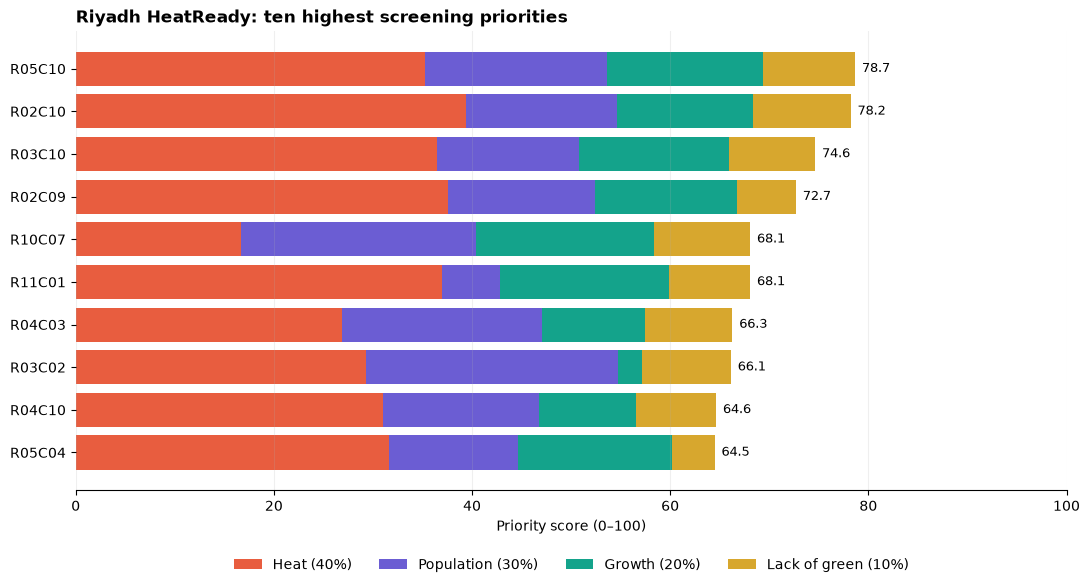

Saved: results\example_priority_output.png


In [4]:
output_columns = [

    "grid_id", "longitude", "latitude", "priority_score", "priority_class",

    "lst_mean_c", "population_estimate", "new_built_fraction", "ndvi_mean_2025",

]

zones[output_columns].to_csv(RESULTS / "example_priority_zones.csv", index=False)



top = zones.head(10).sort_values("priority_score")

parts = [

    ("Heat (40%)", "heat_component", 40, "#E85D3F"),

    ("Population (30%)", "population_component", 30, "#6B5DD3"),

    ("Growth (20%)", "growth_component", 20, "#14A38B"),

    ("Lack of green (10%)", "lack_green_component", 10, "#D7A72E"),

]

fig, ax = plt.subplots(figsize=(11, 6.2))

left = np.zeros(len(top))

for label, column, maximum, color in parts:

    value = top[column].to_numpy() * maximum

    ax.barh(top["grid_id"], value, left=left, label=label, color=color)

    left += value

for y, score in enumerate(top["priority_score"]):

    ax.text(score + 0.7, y, f"{score:.1f}", va="center", fontsize=9)

ax.set_xlim(0, 100)

ax.set_xlabel("Priority score (0–100)")

ax.set_title("Riyadh HeatReady: ten highest screening priorities", loc="left", weight="bold")

ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.12), frameon=False)

ax.grid(axis="x", alpha=0.2)

ax.spines[["top", "right", "left"]].set_visible(False)

fig.tight_layout()

fig.subplots_adjust(bottom=0.20)

figure_path = RESULTS / "example_priority_output.png"

fig.savefig(figure_path, dpi=180, bbox_inches="tight", facecolor="white")

plt.show()

print(f"Saved: {figure_path.relative_to(ROOT)}")


## What the result means

The highest-ranked cell is **R05C10** with a score of about **78.7**. It combines high land-surface heat, modelled population, confirmed growth, and little vegetation. A planning team would inspect this zone first, compare it with local plans and field conditions, and only then consider an intervention.

## Main limitations

- Land-surface temperature is not air temperature or personal heat exposure.

- WorldPop is a modelled estimate, not a live census or worker count.

- Satellite change can confuse bright roofs, compacted soil, and bare desert.

- The validation reference is also satellite-derived, so it is agreement rather than field accuracy.

- The score weights and thresholds must be reviewed with a real municipal user.
